In [1]:
from IPython.display import HTML
HTML("<style>.container{width:100%!important;margin:auto}div.cell,div.input_area{padding:2px;margin:0}div.output_wrapper{padding:0;margin:0}</style>")

# Machine Learning

**Prerequisites you already have:** Python programming, Linear Algebra (vectors, matrices, dot products)

---
### Learning Objectives
By the end of this notebook, you will be able to:
1. Explain what a regression problem is and how it differs from classification
2. Write down the hypothesis (model) function for linear regression
3. Derive and explain the Mean Squared Error (MSE) loss function
4. Understand Gradient Descent and the math behind the update rule
5. Implement linear regression **from scratch** using only NumPy (so you see every calculation)
6. Implement linear regression using **scikit-learn** (industry-standard tool) --To be 
7. Evaluate a model using R², MSE, and RMSE -----To be
8. Visualize predictions, residuals, and the loss curve --To be


# Part 1: What is a Regression Problem?

In Machine Learning, a **regression problem** is one where we try to predict a **continuous numeric value**.

| Problem | Type | Example Output |
|---|---|---|
| Predict house price from size | Regression | $250,000 |
| Predict tomorrow's temperature | Regression | 24.5°C |
| Predict if an email is spam | Classification | Yes/No |
| Predict digit in an image (0-9) | Classification | "7" |

**Linear Regression** specifically assumes the relationship between the input(s) and the output is a **straight line** (or a flat plane/hyperplane in higher dimensions).

### Real-world example we'll use today:
We want to predict a student's **exam score** based on the **number of hours they studied**. This is a simple, intuitive dataset to understand every formula clearly before moving to bigger, real datasets.


# Part 2: The Model — Hypothesis Function

## Simple Linear Regression (1 feature)

When we have **one input feature** $x$ (e.g., hours studied) and want to predict one output $y$ (e.g., exam score), we assume:

$$
\hat{y} = w \cdot x + b
$$

Where:
- $\hat{y}$ (y-hat) = the **predicted** value (our model's guess)
- $x$ = the input feature (hours studied)
- $w$ = the **weight** (also called *slope* or *coefficient*) — how much $y$ changes per unit of $x$
- $b$ = the **bias** (also called *intercept*) — the predicted value when $x = 0$

This is EXACTLY the equation of a straight line you learned in algebra: $y = mx + c$. In ML, we just rename $m \to w$ and $c \to b$.

---

## Multiple Linear Regression (many features) — where Linear Algebra comes in

Real datasets usually have many features. For example, predicting exam score from:
- Hours studied ($x_1$)
- Hours slept ($x_2$)
- Number of practice tests taken ($x_3$)

Now our model becomes:

$$
\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + b
$$

This generalizes to $n$ features:

$$
\hat{y} = \sum_{i=1}^{n} w_i x_i + b
$$

### Vectorized form (this is why Linear Algebra matters!)

Instead of writing a long sum, we use vectors:

$$
\hat{y} = \mathbf{w}^T \mathbf{x} + b
$$

Where $\mathbf{w} = [w_1, w_2, ..., w_n]$ and $\mathbf{x} = [x_1, x_2, ..., x_n]$ are vectors, and $\mathbf{w}^T \mathbf{x}$ is just the **dot product** you learned in Linear Algebra.

### For an entire dataset (matrix form)

If we have $m$ training examples, we stack them into a matrix $X$ (shape: $m \times n$), and:

$$
\hat{\mathbf{y}} = X\mathbf{w} + b
$$

This single matrix multiplication computes predictions for **all** data points at once — this is exactly why we studied matrix multiplication in linear algebra. Libraries like NumPy do this extremely fast.


In [2]:
# Let's make this concrete with actual numbers before writing any "learning" code.
import numpy as np

# Suppose we already KNOW good values for w and b (we'll learn them properly later)
w = 5      # slope: each extra hour of study adds 5 points
b = 50     # bias: base score with 0 hours studied

# One student studied 4 hours
x = 4
y_hat = w * x + b
print(f"Predicted score for a student who studied {x} hours: {y_hat}")

# Now let's do it for multiple students at once using vectors (this is the linear algebra part!)
hours_studied = np.array([1, 2, 3, 4, 5, 6, 7, 8])   # x vector
predictions = w * hours_studied + b                    # vectorized computation, no loop needed!
print("Predictions for all students:", predictions)


Predicted score for a student who studied 4 hours: 70
Predictions for all students: [55 60 65 70 75 80 85 90]


# Part 3: How do we know if our model is GOOD? — The Loss Function

Above, we just *picked* $w=5$ and $b=50$. But how do we know if these are the **best** values?

We need a way to measure **how wrong** our predictions are compared to the real, actual values. This measurement is called a **Loss Function** (or Cost Function).

## Residual (Error) for one point

For a single data point $i$:

$$
\text{error}_i = \hat{y}_i - y_i
$$

Where $y_i$ is the **actual/true** value and $\hat{y}_i$ is our **predicted** value.

### Why not just add up all the errors?

If we simply summed the errors, positive and negative errors would **cancel out**, making a bad model look good. For example, an error of $+10$ and an error of $-10$ would sum to $0$, hiding the fact that our model was off by 10 points on both.

## Mean Squared Error (MSE) — the standard loss for regression

We square each error (this makes it positive AND penalizes large errors more heavily), then average over all $m$ data points:

$$
MSE = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

### Breaking this formula down piece by piece:
1. $(\hat{y}_i - y_i)$ → how far off was prediction $i$?
2. $(\hat{y}_i - y_i)^2$ → squaring makes it positive, and penalizes big mistakes much more than small ones (an error of 10 becomes 100, an error of 2 becomes only 4)
3. $\sum_{i=1}^{m}$ → add up the squared errors for every one of the $m$ data points
4. $\frac{1}{m}$ → divide by the number of points to get the **average** — so MSE doesn't just get bigger with more data

**Goal of training:** Find the $w$ and $b$ that make MSE as **small as possible**.

This is why it's called the "loss" — it represents how much our model is "losing" (i.e., how wrong it is). A perfect model has $MSE = 0$.


In [3]:
# Let's calculate MSE by hand for our example above, then verify with a formula

# Actual exam scores (ground truth) for students who studied [1,2,3,4,5,6,7,8] hours
y_actual = np.array([54, 61, 64, 71, 74, 79, 86, 89])

# Our model's predictions from before (w=5, b=50)
y_pred = w * hours_studied + b
print("Predictions:", y_pred)
print("Actual:     ", y_actual)

# Step 1: calculate the error (residual) for each point
errors = y_pred - y_actual
print("\nErrors (predicted - actual):", errors)

# Step 2: square each error
squared_errors = errors ** 2
print("Squared errors:", squared_errors)

# Step 3 & 4: sum them up and divide by number of points (mean)
mse = np.mean(squared_errors)
print(f"\nMean Squared Error (MSE) = {mse:.2f}")

# We can also do this in one line using the formula directly:
mse_one_line = np.mean((y_pred - y_actual) ** 2)
print(f"MSE (one-liner check) = {mse_one_line:.2f}")


Predictions: [55 60 65 70 75 80 85 90]
Actual:      [54 61 64 71 74 79 86 89]

Errors (predicted - actual): [ 1 -1  1 -1  1  1 -1  1]
Squared errors: [1 1 1 1 1 1 1 1]

Mean Squared Error (MSE) = 1.00
MSE (one-liner check) = 1.00


# Part 4: Gradient Descent — How the Model Actually Learns

We know MSE tells us how wrong we are. But how do we find the $w$ and $b$ that make MSE the **smallest**?

## The Loss Surface (intuition first)

Imagine plotting MSE for every possible value of $w$ and $b$. This creates a bowl-shaped 3D surface (for linear regression, it's always a smooth "bowl" shape, mathematically called **convex**). Our goal is to find the lowest point of this bowl.

**Gradient Descent** is like standing on a foggy hillside and trying to reach the bottom: you can't see the whole landscape, but you can feel which direction is "downhill" right where you're standing. You take a small step in that direction, then repeat.

## The Math: Derivatives tell us the "downhill direction"

The **gradient** is just the derivative (slope) of the loss function with respect to each parameter. It tells us:
- Which direction increases the loss (uphill)
- How steep it is

Since we want to **decrease** loss, we move in the **opposite** direction of the gradient.

### Deriving the gradient for $w$ (calculus, explained step by step)

Our loss function (for simple linear regression, $\hat{y}_i = wx_i + b$):

$$
MSE = \frac{1}{m}\sum_{i=1}^{m}(wx_i + b - y_i)^2
$$

Taking the partial derivative with respect to $w$ (using the chain rule):

$$
\frac{\partial \, MSE}{\partial w} = \frac{2}{m}\sum_{i=1}^{m}(wx_i + b - y_i)\cdot x_i
$$

**In plain English:** this tells us, for each data point, how much increasing $w$ slightly would increase the loss, weighted by how large that data point's $x$ value is, then averaged over all points.

Similarly, the partial derivative with respect to $b$:

$$
\frac{\partial \, MSE}{\partial b} = \frac{2}{m}\sum_{i=1}^{m}(wx_i + b - y_i)
$$

(Same idea, but without the extra $x_i$ multiplier, since $b$ affects every prediction equally.)

## The Update Rule

At each step, we nudge $w$ and $b$ a small amount in the *negative* gradient direction:

$$
w := w - \alpha \cdot \frac{\partial \, MSE}{\partial w}
$$
$$
b := b - \alpha \cdot \frac{\partial \, MSE}{\partial b}
$$

Where $\alpha$ (alpha) is the **learning rate** — a small number (e.g., 0.01) that controls **how big a step** we take.

- Too **large** a learning rate → we overshoot the bottom of the bowl and may never converge (or even diverge)
- Too **small** a learning rate → training is extremely slow, taking forever to reach the bottom

We repeat this update process for many **iterations** (also called **epochs**) until the loss stops decreasing significantly.


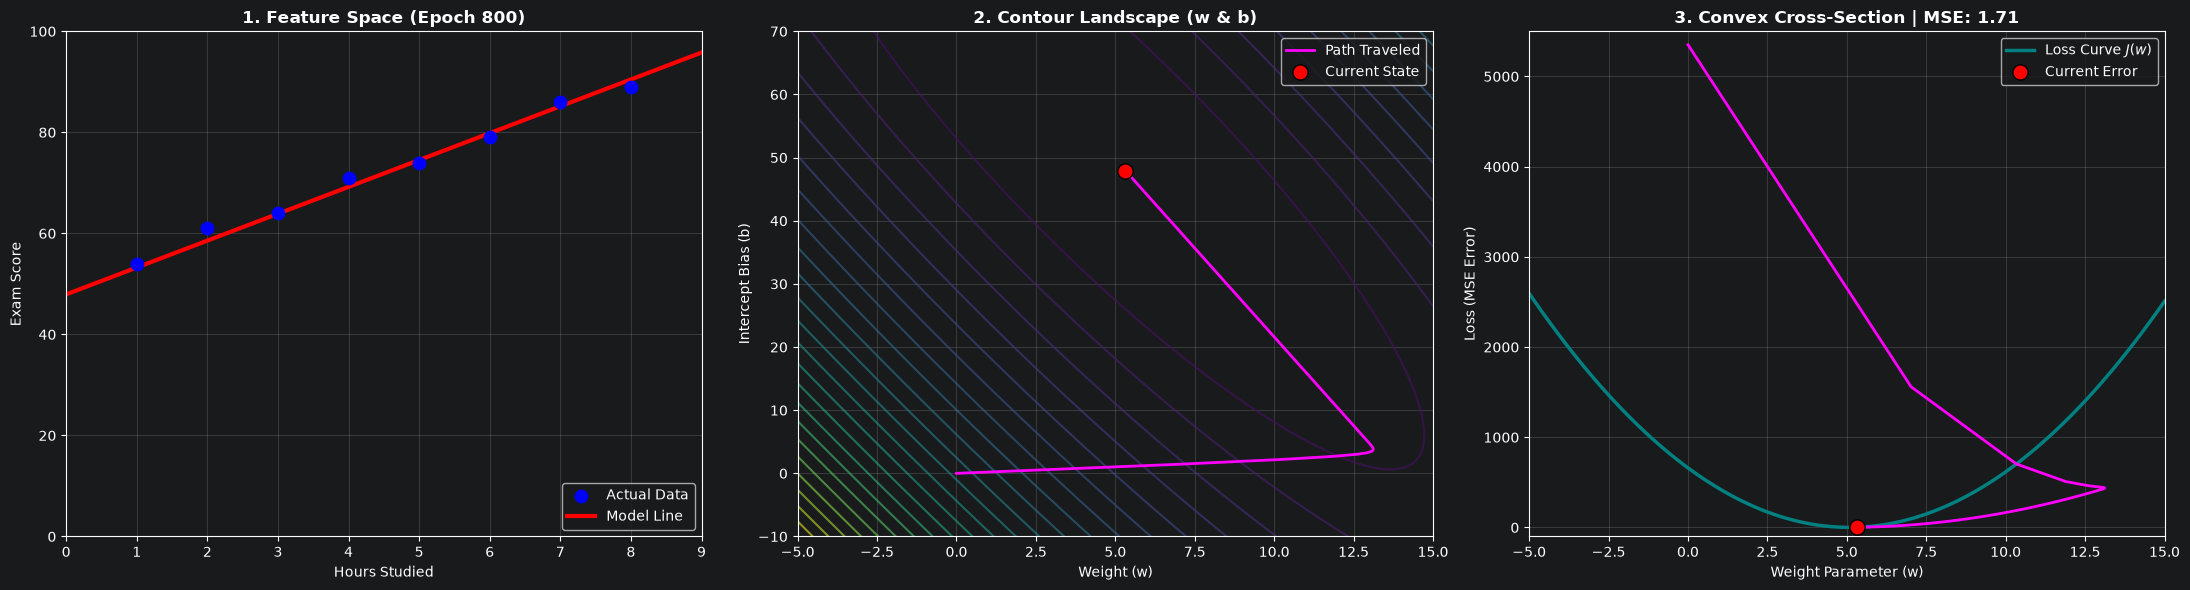

Optimization finished successfully! Final parameters: w = 5.3189, b = 47.9304


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import time

# 1. Dataset
X = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
y = np.array([54, 61, 64, 71, 74, 79, 86, 89], dtype=float)
m = len(X)

# 2. Pre-compute the 3D/2D Loss Landscape for background contours
w_vals = np.linspace(-5, 15, 100)
b_vals = np.linspace(-10, 70, 100)
W_grid, B_grid = np.meshgrid(w_vals, b_vals)
Loss_grid = np.zeros_like(W_grid)

for i in range(W_grid.shape[0]):
    for j in range(W_grid.shape[1]):
        y_pred_grid = W_grid[i, j] * X + B_grid[i, j]
        Loss_grid[i, j] = np.mean((y_pred_grid - y) ** 2)

# Pre-compute the 2D Convex Curve for w ---
# We fix b at its target optimal value (~49.2) to showcase a perfect cross-section U-curve
fixed_b = 49.2321
loss_curve_w = []
for wi in w_vals:
    y_pred_curve = wi * X + fixed_b
    loss_curve_w.append(np.mean((y_pred_curve - y) ** 2))

# 3. Initialize Gradient Descent variables
w = 0.0
b = 0.0
learning_rate = 0.01
epochs = 801

# Track historical coordinates to trace paths
w_history = []
b_history = []
loss_history = []

for epoch in range(epochs):
    # Forward Pass & Loss tracking
    y_pred = w * X + b
    loss = np.mean((y_pred - y) ** 2)
    
    w_history.append(w)
    b_history.append(b)
    loss_history.append(loss)

    # Gradient Calculation
    dw = (2/m) * np.sum((y_pred - y) * X)
    db = (2/m) * np.sum((y_pred - y))

    # Parameter Update
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # ---- THREE-PANEL SIDE-BY-SIDE ANIMATION LOGIC ----
    if epoch % 20 == 0:
        display.clear_output(wait=True)
        
        # Setup 3 axes plot windows side-by-side
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))
        
        # --- PANEL 1: Line Fitting (Feature Space) ---
        ax1.scatter(X, y, color='blue', s=80, zorder=5, label='Actual Data')
        X_line = np.linspace(0, 9, 100)
        ax1.plot(X_line, w * X_line + b, color='red', lw=3, label='Model Line')
        ax1.set_xlim(0, 9)
        ax1.set_ylim(0, 100)
        ax1.set_title(f"1. Feature Space (Epoch {epoch})", fontsize=12, fontweight='bold')
        ax1.set_xlabel("Hours Studied")
        ax1.set_ylabel("Exam Score")
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc="lower right")
        
        # --- PANEL 2: Bird's-Eye View Topography (2 Parameters) ---
        ax2.contour(W_grid, B_grid, Loss_grid, levels=25, cmap='viridis', alpha=0.6)
        ax2.plot(w_history, b_history, color='magenta', linestyle='-', lw=2, label='Path Traveled')
        ax2.scatter(w, b, color='red', s=120, edgecolor='black', zorder=10, label='Current State')
        ax2.set_xlim(-5, 15)
        ax2.set_ylim(-10, 70)
        ax2.set_title(f"2. Contour Landscape (w & b)", fontsize=12, fontweight='bold')
        ax2.set_xlabel("Weight (w)")
        ax2.set_ylabel("Intercept Bias (b)")
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc="upper right")
        
        # --- PANEL 3: NEW! Convex U-Curve Cross-Section (1 Parameter) ---
        ax3.plot(w_vals, loss_curve_w, color='teal', lw=2.5, label='Loss Curve $J(w)$')
        # Plot path traveled along the side of the bowl
        ax3.plot(w_history, loss_history, color='magenta', linestyle='-', lw=2)
        # Current status ball rolling down
        ax3.scatter(w, loss, color='red', s=120, edgecolor='black', zorder=10, label='Current Error')
        ax3.set_xlim(-5, 15)
        ax3.set_ylim(-100, 5500)
        ax3.set_title(f"3. Convex Cross-Section | MSE: {loss:.2f}", fontsize=12, fontweight='bold')
        ax3.set_xlabel("Weight Parameter (w)")
        ax3.set_ylabel("Loss (MSE Error)")
        ax3.grid(True, alpha=0.3)
        ax3.legend(loc="upper right")
        
        plt.tight_layout()
        plt.show()
        time.sleep(0.04)

print(f"Optimization finished successfully! Final parameters: w = {w:.4f}, b = {b:.4f}")

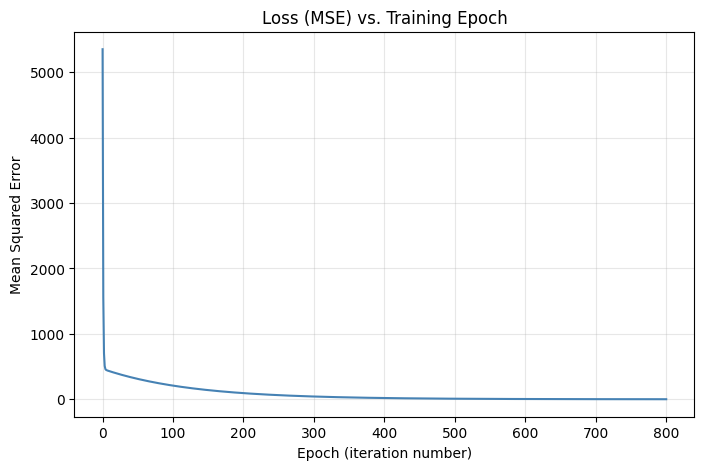

Notice: the loss drops FAST at first, then flattens out.
This flattening means gradient descent is converging -- it has nearly reached the bottom of the bowl.


In [5]:
    # Visualize the Loss Curve: this shows the model LEARNING over time
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='steelblue')
plt.title("Loss (MSE) vs. Training Epoch")
plt.xlabel("Epoch (iteration number)")
plt.ylabel("Mean Squared Error")
plt.grid(True, alpha=0.3)
plt.show()

print("Notice: the loss drops FAST at first, then flattens out.")
print("This flattening means gradient descent is converging -- it has nearly reached the bottom of the bowl.")


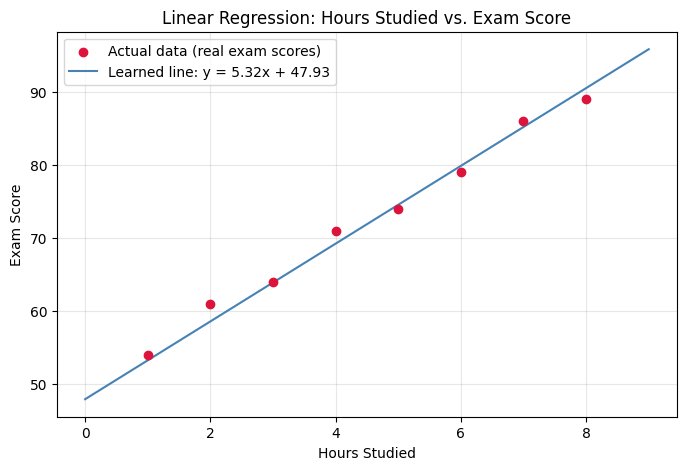

In [6]:
# Visualize the final fitted line against our actual data points
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='crimson', label='Actual data (real exam scores)', zorder=3)

x_line = np.linspace(0, 9, 100)
y_line = w * x_line + b
plt.plot(x_line, y_line, color='steelblue', label=f'Learned line: y = {w:.2f}x + {b:.2f}')

plt.title("Linear Regression: Hours Studied vs. Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Recap

| Concept | What it means |
|---|---|
| Hypothesis $\hat{y} = wx + b$ | Our model's equation for predicting a value |
| MSE Loss | A single number measuring how wrong our predictions are |
| Gradient | The derivative telling us which direction increases loss |
| Gradient Descent | Repeatedly stepping in the opposite (downhill) direction to reduce loss |
| Learning rate ($\alpha$) | How big each step is |
| Epoch | One full pass of updating $w$ and $b$ |

Take a short break here if needed — Hour 3 moves into practical, real-world coding using scikit-learn!
